# Milestone 3: Exploratory Data Analysis (EDA)

In [14]:
import os
os.chdir("/workspaces/group-project-team2/checkpoint/data_acquisition/")

import pandas as pd
import numpy as np

brfss1 = pd.read_parquet("BRFSS_2024_1.parquet.gzip")
brfss2 =  pd.read_parquet("BRFSS_2024_2.parquet.gzip")

: 

In [ ]:
brfss = pd.concat([brfss1, brfss2], axis = 0)

In [ ]:
brfss.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0


In [ ]:
columns_list = brfss.columns.tolist()
print(columns_list)

['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES2', 'SMALST

## Selecting Relevant Features


- **_AGE_G (Age Group)**: Essential demographic variable that allows for age-stratified analysis and controls for age-related health patterns in outcome assessment.

- **_SEX (Sex)**: Key demographic predictor as health outcomes and risk factors often differ significantly between males and females.

- **_BMI5 (Body Mass Index)**: Direct quantitative measure of body weight relative to height, crucial for assessing weight-related health risks.

- **_RFBMI5 (Obese)**: Binary obesity classification derived from BMI, serving as a primary outcome variable for identifying obesity prevalence and risk factors.

- **HTM4 (Height)**: Anthropometric measure needed for BMI calculations and body composition assessments.

- **_TOTINDA (Physical Activity)**: Important behavioral variable; physical activity is a known protective factor against obesity and chronic diseases.

- **WTKG3 (Weight)**: Direct weight measurement in kilograms, essential for BMI computation and weight status classification.

- **_RFSMOK3 (Smoking Status)**: Significant lifestyle factor that influences metabolism, weight patterns, and overall health outcomes.

- **_RFDRHV9 (Heavy Drinker)**: Behavioral risk factor; heavy alcohol consumption is associated with various health outcomes including weight gain.

- **_EDUCAG (Education Level)**: Socioeconomic indicator that often correlates with health literacy, lifestyle choices, and health outcomes.

- **_INCOMG1 (Income Category)**: Socioeconomic variable affecting access to healthcare, healthy food options, and health-related resources.

## Primary Outcomes
- Obesity prevalence and classification
- Identification of demographic and behavioral risk factors associated with obesity
- Understanding socioeconomic disparities in weight-related health outcomes


In [ ]:
cols = ["_AGE_G", "_SEX","_BMI5","_RFBMI5","HTM4", "_TOTINDA","WTKG3", "_RFSMOK3",
        "_RFDRHV9","_EDUCAG" , "_INCOMG1"]
data = brfss[cols]

## Renaming Variable Names 

In [ ]:

# Renaming Variable Names

data = data.rename(columns={ "_SEX": "Sex",
                           "_BMI5": "BMI",
                           "_AGE_G": "Age_group",
                           "_RFBMI5": "Obese",
                           "HTM4": "Height(m)",
                           "_TOTINDA": "Physical_Activity",
                           "WTKG3": "Weight(kg)",
                           "_RFSMOK3": "Smoker",
                           "_RFDRHV9": "Heavy_Drinker",
                           "_EDUCAG": "Education_level",
                           "_INCOMG1": "Income_Cat"
                         })
data.columns

Index(['Age_group', 'Sex', 'BMI', 'Obese', 'Height(m)', 'Physical_Activity',
       'Weight(kg)', 'Smoker', 'Heavy_Drinker', 'Education_level',
       'Income_Cat'],
      dtype='str')

In [ ]:
data.head()

,Age_group,Sex,BMI,Obese,Height(m),Physical_Activity,Weight(kg),Smoker,Heavy_Drinker,Education_level,Income_Cat
0,6.0,2.0,2249.0,1.0,163.0,1.0,5942.0,1.0,1.0,2.0,9.0
1,6.0,1.0,2583.0,2.0,178.0,1.0,8165.0,1.0,1.0,4.0,7.0
2,5.0,1.0,2253.0,1.0,198.0,1.0,8845.0,2.0,1.0,3.0,9.0
3,6.0,1.0,2509.0,2.0,173.0,1.0,7484.0,1.0,1.0,4.0,4.0
4,4.0,1.0,1977.0,1.0,173.0,2.0,5897.0,1.0,1.0,3.0,2.0


# Recoding Variables from Numeric to Categorical Format
- Converting Income Categories from Numeric Codes to Ordered Factor Labels:
 Preserves the natural hierarchy of income levels for appropriate statistical analysis.

- Transforming Education Level from Numeric Values to Ordered Categorical Variable:
 Captures the progressive nature of educational attainment from no diploma through college graduation.

- Recoding Heavy Drinker Status from Numeric to Categorical Format:
 Improves interpretability by using descriptive "Yes"/"No" labels for this binary variable.

- Converting Smoking Status from Numeric Codes to Binary Categories:
  Makes the data self-documenting and prevents numeric codes from being misinterpreted as quantitative.

- Mapping Physical Activity Variable from Numeric to Descriptive Categories:Provides clear, descriptive labels that eliminate ambiguity in understanding activity status.

- Transforming Age Group from Numeric Codes to Ordered Categorical Levels: Maintains the natural age progression for demographic analyses and stratification.

- Converting Sex Variable from Numeric to Character Labels: Eliminates the need for codebook reference by using immediately interpretable labels.

- Recoding Obesity Status from Numeric to Binary Categorical Format: Clearly communicates health status using straightforward "Yes"/"No" categories.

In [ ]:

# Mapping Values In Categorical Variables ... Changing them From Numeric to Categories

# INCOME

# Converting  income var to integer
data["Income_Cat"] = data["Income_Cat"].astype("Int64")

# Ordered income categories
income_order = [
        "Less than $15,000",
        "$15,000 < $25,000",
        "$25,000 < $35,000",
        "$35,000 < $50,000",
        "$50,000 < $100,000",
        "$100,000 < $200,000",
        "$200,000 or more",
        "Missing/Don’t know",
]

# Replacing numeric codes with categories 
data["Income_Cat"] = pd.Categorical(
    data["Income_Cat"].map({
        1: "Less than $15,000",
        2: "$15,000 < $25,000",
        3: "$25,000 < $35,000",
        4: "$35,000 < $50,000",
        5: "$50,000 < $100,000",
        6: "$100,000 < $200,000",
        7: "$200,000 or more",
        9: np.nan
    }),
    categories = income_order,
    ordered = True
)

# EDUCATION

# Converting  education variable to integer 
data["Education_level"] = data["Education_level"].astype("Int64")

# Ordered education categories
education_order = [
    "Did not graduate High School",
    "Graduated High School",
    "Attended College or Technical School",
    "Graduated from College or Technical School",
    "Don’t know/Not sure/Missing"
]

# Replace numeric codes with categories and create an ordered categorical
data["Education_level"] = pd.Categorical(
    data["Education_level"].map({
        1: "Did not graduate High School",
        2: "Graduated High School",
        3: "Attended College or Technical School",
        4: "Graduated from College or Technical School",
        9: np.nan
    }),
    categories=education_order,
    ordered=True
)

# ALCOHOL

# Converting the column to integer
data["Heavy_Drinker"] = data["Heavy_Drinker"].astype("Int64")

# Map numeric codes 
data["Heavy_Drinker"] = pd.Categorical(
    data["Heavy_Drinker"].map({
        1: "No",
        2: "Yes",
        9: np.nan
    })
)

# SMOKING 

# Converting  column to integer 
data["Smoker"] = data["Smoker"].astype("Int64")

# Map numeric codes to categor
data["Smoker"] = pd.Categorical(
    data["Smoker"].map({
        1: "No",
        2: "Yes",
        9: np.nan 
    })
)

# OBESE

# Converting column to integer 
data["Obese"] = data["Obese"].astype("Int64")

# Mapping numeric codes to categories
data["Obese"] = data["Obese"].map({
    1: "No",
    2: "Yes",
    9: np.nan 
})

# SEX

# Converting to integer 
data["Sex"] = data["Sex"].astype("Int64")

# Mapping numeric codes to categories
data["Sex"] = data["Sex"].map({
    1: "Male",
    2: "Female"
})

# AGE GROUP

# Converting column to integer 
data["Age_group"] = data["Age_group"].astype("Int64")

# Defining the ordered categories
age_order = [
    "Age 18 to 24",
    "Age 25 to 34",
    "Age 35 to 44",
    "Age 45 to 54",
    "Age 55 to 64",
    "Age 65 or older"
]

# Map numeric codes to categories 
data["Age_group"] = pd.Categorical(
    data["Age_group"].map({
        1: "Age 18 to 24",
        2: "Age 25 to 34",
        3: "Age 35 to 44",
        4: "Age 45 to 54",
        5: "Age 55 to 64",
        6: "Age 65 or older"
    }),
    categories=age_order,
    ordered=True
)

# PHYSICAL ACTIVITY

# Converting column to integer 
data["Physical_Activity"] = data["Physical_Activity"].astype("Int64")

data["Physical_Activity"] = pd.Categorical(
    data["Physical_Activity"].map({
        1: "Had physical activity or exercise",
        2: "No physical activity or exercise in last 30 days",
        9: np.nan
    })
)

# M3.T1 — Summary statistics and distributions  

In [ ]:
data.describe(include = "category")

,Age_group,Physical_Activity,Smoker,Heavy_Drinker,Education_level,Income_Cat
count,457670,456355,425648,410972,455307,370247
unique,6,2,2,2,4,7
top,Age 65 or older,Had physical activity or exercise,No,No,Graduated from College or Technical School,"$50,000 < $100,000"
freq,172826,350061,378554,386812,191549,112409


In [ ]:
data.describe()

,BMI,Height(m),Weight(kg)
count,414633.000000,433610.000000,421278.000000
mean,2855.680093,170.165995,8300.484516
std,658.616131,10.822765,2141.833796
min,1200.000000,91.000000,2268.000000
25%,2414.000000,163.000000,6804.000000
50%,2744.000000,170.000000,8074.000000
75%,3175.000000,178.000000,9525.000000
max,9984.000000,241.000000,29030.000000


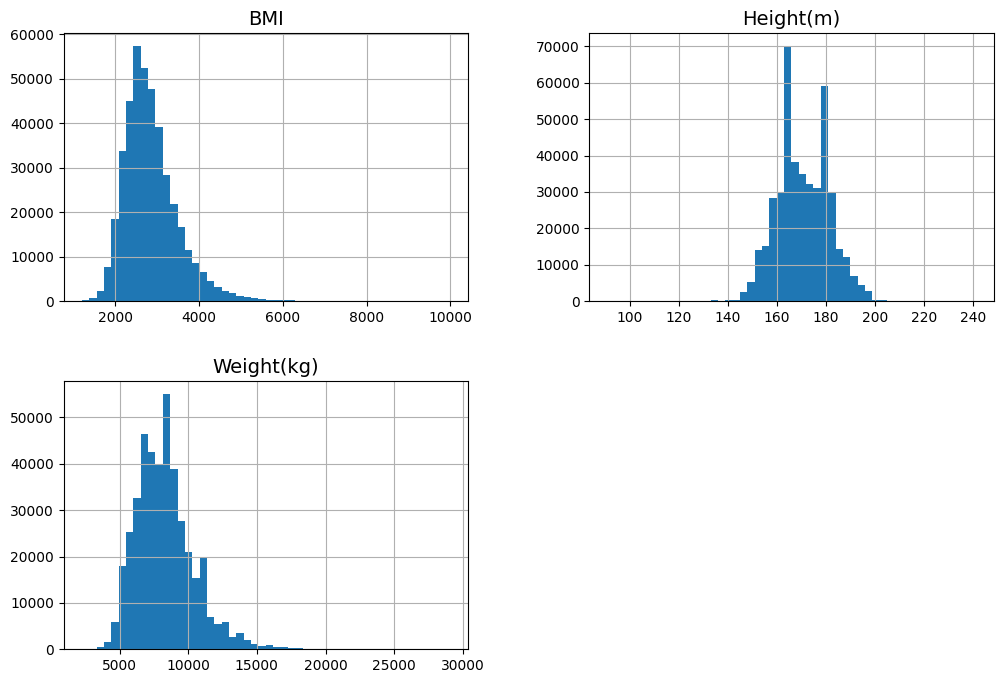

In [ ]:
import matplotlib.pyplot as plt

# Visualizing Variables Distributions

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

data.hist(bins=50, figsize=(12, 8))
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

# 0. COLUMN DEFINITIONS 

ORDINAL_COLS = ["Age_group", "Education_level", "Income_Cat"]

ORDINAL_ORDERS = [
    ["Age 18 to 24", "Age 25 to 34", "Age 35 to 44",
     "Age 45 to 54", "Age 55 to 64", "Age 65 or older"],

    ["Did not graduate High School", "Graduated High School",
     "Attended College or Technical School",
     "Graduated from College or Technical School",
     "Don't know/Not sure/Missing"],

    ["Less than $15,000", "$15,000 < $25,000", "$25,000 < $35,000",
     "$35,000 < $50,000", "$50,000 < $100,000",
     "$100,000 < $200,000", "$200,000 or more", "Missing/Don't know"],
]

# Sex, Smoker, Heavy_Drinker, Physical_Activity
# OrdinalEncoder handles binary cols too — order doesn't matter for 2-class cols
BINARY_COLS = ["Sex", "Smoker", "Heavy_Drinker", "Physical_Activity"]

# Drop before anything else — direct leakage into target (Obese)
LEAKAGE_COLS = ["BMI", "Height(m)", "Weight(kg)"]


# 1. SPLIT TARGET & DROP LEAKAGE 

X = data.drop(columns=["Obese"] + LEAKAGE_COLS)
y = data["Obese"].map({"No": 0, "Yes": 1})


# 2. ORDINAL PIPELINE
# Impute with most_frequent first (SimpleImputer needs strings, not NaN),
# then encode the ordered categories to integers.

ordinal_pipe = Pipeline(steps=[
    ("impute",  SimpleImputer(strategy="most_frequent")),
    ("encode",  OrdinalEncoder(
                    categories=ORDINAL_ORDERS,
                    handle_unknown="use_encoded_value",
                    unknown_value=np.nan
                )),
])


#  3. BINARY PIPELINE

binary_pipe = Pipeline(steps=[
    ("impute",  SimpleImputer(strategy="most_frequent")),
    ("encode",  OrdinalEncoder()),  # 2 classes only — order doesn't affect the model
])


# 4. COLUMN TRANSFORMER

preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_pipe, ORDINAL_COLS),
        ("binary",  binary_pipe,  BINARY_COLS),
    ],
    remainder="drop"   # drops anything not listed — no accidental leakage
)


# 5. Fitting and Transforming

X_clean = preprocessor.fit_transform(X)

# Recover column names
feature_names = ORDINAL_COLS + BINARY_COLS
X_clean = pd.DataFrame(X_clean, columns=feature_names)

print("Shape:", X_clean.shape)
print("\nMissing values:\n", X_clean.isnull().sum())
print("\nSample:\n", X_clean.head())
print("\nTarget distribution:\n", y.value_counts(normalize=True))

Shape: (457670, 7)

Missing values:
 Age_group            0
Education_level      0
Income_Cat           0
Sex                  0
Smoker               0
Heavy_Drinker        0
Physical_Activity    0
dtype: int64

Sample:
    Age_group  Education_level  Income_Cat  Sex  Smoker  Heavy_Drinker  \
0        5.0              1.0         4.0  0.0     0.0            0.0   
1        5.0              3.0         6.0  1.0     0.0            0.0   
2        4.0              2.0         4.0  1.0     1.0            0.0   
3        5.0              3.0         3.0  1.0     0.0            0.0   
4        3.0              2.0         1.0  1.0     0.0            0.0   

   Physical_Activity  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                1.0  

Target distribution:
 Obese
1.0    0.690256
0.0    0.309744
Name: proportion, dtype: float64


# M3.T2 — Visualize correlations, feature importance, and risk clusters  


NameError: name 'sns' is not defined